# Exploratory Data Analysis: GoodBooks-10k

This notebook explores the GoodBooks-10k dataset used for the mlops-bookclub project.

Dataset source: [GoodBooks-10k](https://github.com/zygmuntz/goodbooks-10k)

## Dataset Context

GoodBooks-10k contains around six million ratings for 10,000 popular books. It also includes books marked as to-read, book metadata, and user-generated tags/shelves/genres.

Important table notes:
- `ratings.csv`: `user_id`, `book_id`, `rating`; ratings are integers from 1 to 5.
- `to_read.csv`: `user_id`, `book_id` pairs for books users marked as to-read.
- `books.csv`: metadata such as Goodreads IDs, authors, titles, publication years, and average ratings.
- `book_tags.csv`: tag assignments using `goodreads_book_id` and `tag_id`.
- `tags.csv`: maps `tag_id` to human-readable tag names.

ID handling:
- Use `book_id` when connecting ratings or to-read entries to `books.csv`.
- Use `goodreads_book_id` when connecting `book_tags.csv` to `books.csv`.
- `goodreads_book_id`, `best_book_id`, and `work_id` are Goodreads identifiers and should not be mixed with the internal `book_id` without checking the intended join.

## Setup

The helper functions below format large numbers with thousands separators, so values such as `2e6` are shown as `2,000,000`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"


def fmt_int(value):
    return f"{int(value):,}"


def fmt_float(value, digits=2):
    return f"{value:,.{digits}f}"


def fmt_pct(value, digits=2):
    return f"{value:.{digits}f}%"


def fmt_millions(value, digits=1):
    return f"{value / 1_000_000:,.{digits}f} million"


def integer_axis(ax, axis="y"):
    formatter = FuncFormatter(lambda value, _: f"{value:,.0f}")
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)
    return ax


DATA_DIR

WindowsPath('C:/Users/sv3nl/Documents/HSLU/MLOps/book-recommender/data/raw')

## Dataset Inventory

In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

inventory = pd.DataFrame(
    {
        "file": [path.name for path in csv_files],
        "size": [f"{path.stat().st_size / 1024**2:,.2f} MB" for path in csv_files],
    }
)

inventory

,file,size
0,book_tags.csv,15.89 MB
1,books.csv,3.13 MB
2,ratings.csv,68.79 MB
3,tags.csv,0.69 MB
4,to_read.csv,8.97 MB


In [3]:
books = pd.read_csv(DATA_DIR / "books.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
book_tags = pd.read_csv(DATA_DIR / "book_tags.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")
to_read = pd.read_csv(DATA_DIR / "to_read.csv")

tables = {
    "books": books,
    "ratings": ratings,
    "book_tags": book_tags,
    "tags": tags,
    "to_read": to_read,
}

summary = pd.DataFrame(
    {
        "table": list(tables),
        "rows": [fmt_int(len(df)) for df in tables.values()],
        "columns": [fmt_int(df.shape[1]) for df in tables.values()],
    }
)

summary

,table,rows,columns
0,books,"10,000",23
1,ratings,"5,976,479",3
2,book_tags,"999,912",3
3,tags,"34,252",2
4,to_read,"912,705",2


In [4]:
for name, df in tables.items():
    print(f"{name}: {len(df):,} rows x {df.shape[1]:,} columns")
    print(", ".join(df.columns))
    print()

books: 10,000 rows x 23 columns
book_id, goodreads_book_id, best_book_id, work_id, books_count, isbn, isbn13, authors, original_publication_year, original_title, title, language_code, average_rating, ratings_count, work_ratings_count, work_text_reviews_count, ratings_1, ratings_2, ratings_3, ratings_4, ratings_5, image_url, small_image_url

ratings: 5,976,479 rows x 3 columns
user_id, book_id, rating

book_tags: 999,912 rows x 3 columns
goodreads_book_id, tag_id, count

tags: 34,252 rows x 2 columns
tag_id, tag_name

to_read: 912,705 rows x 2 columns
user_id, book_id



## Key Dataset Facts

In [5]:
ratings_per_user = ratings.groupby("user_id").size()
ratings_per_book = ratings.groupby("book_id").size()
to_read_per_user = to_read.groupby("user_id").size()
to_read_per_book = to_read.groupby("book_id").size()

matrix_density = len(ratings) / (
    ratings["user_id"].nunique() * ratings["book_id"].nunique()
) * 100

facts = pd.DataFrame(
    {
        "metric": [
            "ratings",
            "unique users in ratings.csv",
            "unique books in ratings.csv",
            "filled user-book rating pairs",
            "average rating",
            "median ratings per user",
            "median ratings per book",
            "to-read entries",
            "users with to-read entries",
            "books with to-read entries",
        ],
        "value": [
            fmt_int(len(ratings)),
            fmt_int(ratings["user_id"].nunique()),
            fmt_int(ratings["book_id"].nunique()),
            fmt_pct(matrix_density),
            fmt_float(ratings["rating"].mean()),
            fmt_int(ratings_per_user.median()),
            fmt_int(ratings_per_book.median()),
            fmt_int(len(to_read)),
            fmt_int(to_read["user_id"].nunique()),
            fmt_int(to_read["book_id"].nunique()),
        ],
    }
)

facts

,metric,value
0,ratings,"5,976,479"
1,unique users in ratings.csv,"53,424"
2,unique books in ratings.csv,"10,000"
3,filled user-book rating pairs,1.12%
4,average rating,3.92
5,median ratings per user,111
6,median ratings per book,248
7,to-read entries,"912,705"
8,users with to-read entries,"48,871"
9,books with to-read entries,"9,986"


## Missing Values

In [6]:
missing_summary = []

for table_name, df in tables.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    for column, count in missing.items():
        missing_summary.append(
            {
                "table": table_name,
                "column": column,
                "missing_count": fmt_int(count),
                "missing_pct": fmt_pct(count / len(df) * 100),
            }
        )

missing_df = pd.DataFrame(missing_summary)
missing_df

,table,column,missing_count,missing_pct
0,books,language_code,"1,084",10.84%
1,books,isbn,700,7.00%
2,books,isbn13,585,5.85%
3,books,original_title,585,5.85%
4,books,original_publication_year,21,0.21%


## Ratings

In [7]:
rating_counts = ratings["rating"].value_counts().sort_index().reset_index()
rating_counts.columns = ["rating", "count"]
rating_counts["count_formatted"] = rating_counts["count"].map(fmt_int)
rating_counts

,rating,count,count_formatted
0,1,124195,"124,195"
1,2,359257,"359,257"
2,3,1370916,"1,370,916"
3,4,2139018,"2,139,018"
4,5,1983093,"1,983,093"


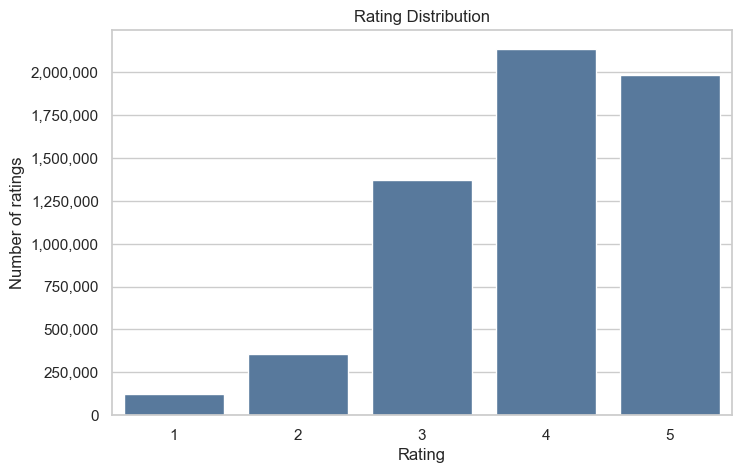

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rating_counts, x="rating", y="count", color="#4C78A8", ax=ax)
integer_axis(ax, "y")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
plt.show()

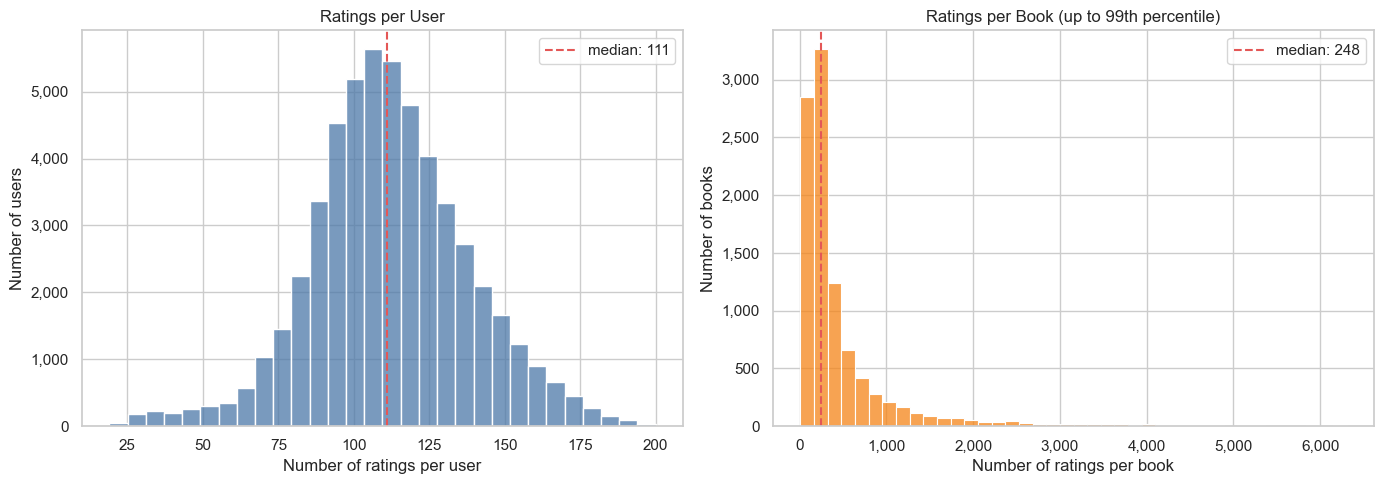

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ratings_per_user, bins=30, ax=axes[0], color="#4C78A8")
axes[0].axvline(ratings_per_user.median(), color="#E45756", linestyle="--", label=f"median: {ratings_per_user.median():,.0f}")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of ratings per user")
axes[0].set_ylabel("Number of users")
axes[0].legend()
integer_axis(axes[0], "x")
integer_axis(axes[0], "y")

book_plot_limit = ratings_per_book.quantile(0.99)
sns.histplot(ratings_per_book[ratings_per_book <= book_plot_limit], bins=40, ax=axes[1], color="#F58518")
axes[1].axvline(ratings_per_book.median(), color="#E45756", linestyle="--", label=f"median: {ratings_per_book.median():,.0f}")
axes[1].set_title("Ratings per Book (up to 99th percentile)")
axes[1].set_xlabel("Number of ratings per book")
axes[1].set_ylabel("Number of books")
axes[1].legend()
integer_axis(axes[1], "x")
integer_axis(axes[1], "y")

plt.tight_layout()
plt.show()


In [10]:
interaction_summary = pd.DataFrame(
    {
        "group": ["users", "books"],
        "min_interactions": [fmt_int(ratings_per_user.min()), fmt_int(ratings_per_book.min())],
        "median_interactions": [fmt_int(ratings_per_user.median()), fmt_int(ratings_per_book.median())],
        "mean_interactions": [fmt_float(ratings_per_user.mean()), fmt_float(ratings_per_book.mean())],
        "max_interactions": [fmt_int(ratings_per_user.max()), fmt_int(ratings_per_book.max())],
    }
)

interaction_summary

,group,min_interactions,median_interactions,mean_interactions,max_interactions
0,users,19,111,111.87,200
1,books,8,248,597.65,"22,806"


## Books

In [11]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,"9,780,439,023,480.00",Suzanne Collins,"2,008.00",The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,"9,780,439,554,930.00","J.K. Rowling, Mary GrandPré","1,997.00",Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,"9,780,316,015,840.00",Stephenie Meyer,"2,005.00",Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,"9,780,061,120,080.00",Harper Lee,"1,960.00",To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,"9,780,743,273,560.00",F. Scott Fitzgerald,"1,925.00",The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [12]:
book_quality_checks = pd.DataFrame(
    {
        "check": [
            "duplicate book_id values",
            "duplicate goodreads_book_id values",
            "duplicate title values",
            "missing original_publication_year values",
            "missing language_code values",
        ],
        "count": [
            fmt_int(books["book_id"].duplicated().sum()),
            fmt_int(books["goodreads_book_id"].duplicated().sum()),
            fmt_int(books["title"].duplicated().sum()),
            fmt_int(books["original_publication_year"].isna().sum()),
            fmt_int(books["language_code"].isna().sum()),
        ],
    }
)
book_quality_checks

,check,count
0,duplicate book_id values,0
1,duplicate goodreads_book_id values,0
2,duplicate title values,36
3,missing original_publication_year values,21
4,missing language_code values,"1,084"


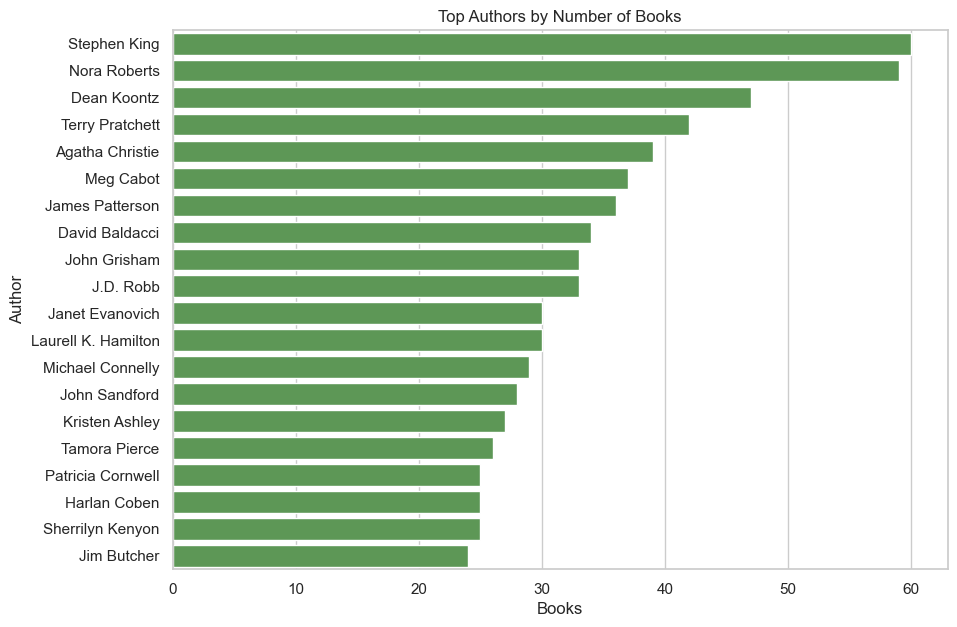

In [13]:
top_authors = books["authors"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_authors.values, y=top_authors.index, color="#54A24B", ax=ax)
integer_axis(ax, "x")
ax.set_title("Top Authors by Number of Books")
ax.set_xlabel("Books")
ax.set_ylabel("Author")
plt.show()

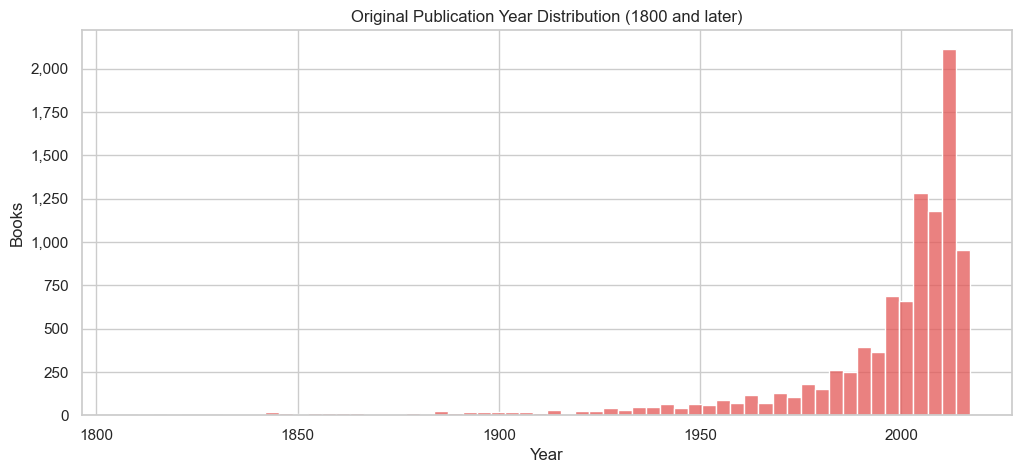

In [14]:
publication_years = books["original_publication_year"].dropna()
publication_years_recent = publication_years[(publication_years >= 1800) & (publication_years <= publication_years.max())]

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(publication_years_recent, bins=60, color="#E45756", ax=ax)
integer_axis(ax, "y")
ax.set_title("Original Publication Year Distribution (1800 and later)")
ax.set_xlabel("Year")
ax.set_ylabel("Books")
plt.show()

## To-Read Data

In [15]:
to_read_summary = pd.DataFrame(
    {
        "metric": ["to-read entries", "users", "books", "median to-read entries per user", "median to-read entries per book"],
        "value": [
            fmt_int(len(to_read)),
            fmt_int(to_read["user_id"].nunique()),
            fmt_int(to_read["book_id"].nunique()),
            fmt_int(to_read_per_user.median()),
            fmt_int(to_read_per_book.median()),
        ],
    }
)
to_read_summary

,metric,value
0,to-read entries,"912,705"
1,users,"48,871"
2,books,"9,986"
3,median to-read entries per user,14
4,median to-read entries per book,42


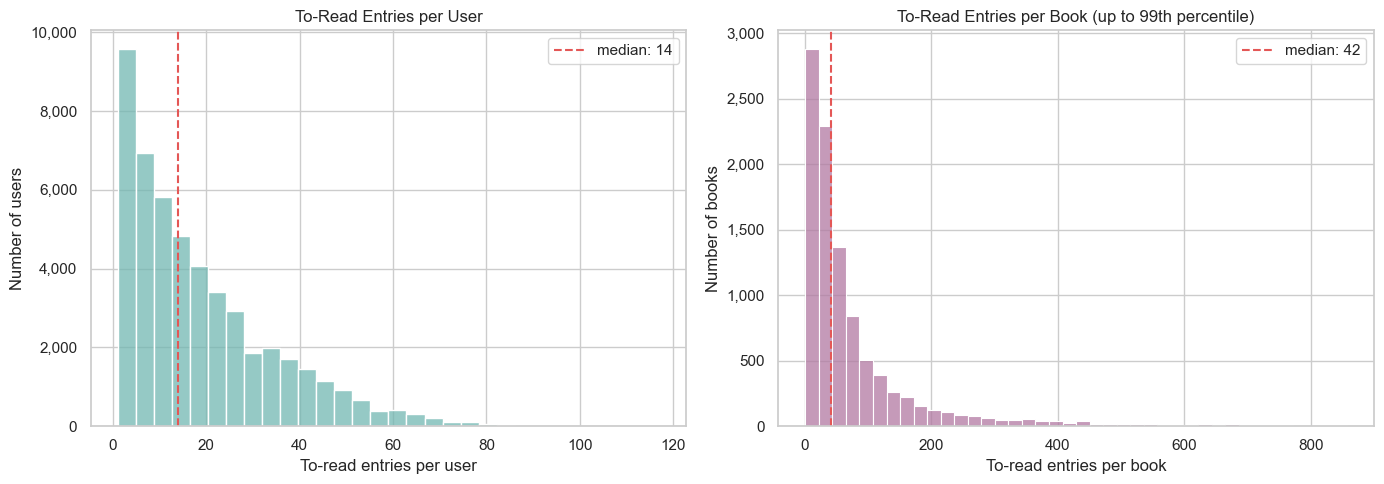

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(to_read_per_user, bins=30, ax=axes[0], color="#72B7B2")
axes[0].axvline(to_read_per_user.median(), color="#E45756", linestyle="--", label=f"median: {to_read_per_user.median():,.0f}")
axes[0].set_title("To-Read Entries per User")
axes[0].set_xlabel("To-read entries per user")
axes[0].set_ylabel("Number of users")
axes[0].legend()
integer_axis(axes[0], "x")
integer_axis(axes[0], "y")

book_to_read_limit = to_read_per_book.quantile(0.99)
sns.histplot(to_read_per_book[to_read_per_book <= book_to_read_limit], bins=40, ax=axes[1], color="#B279A2")
axes[1].axvline(to_read_per_book.median(), color="#E45756", linestyle="--", label=f"median: {to_read_per_book.median():,.0f}")
axes[1].set_title("To-Read Entries per Book (up to 99th percentile)")
axes[1].set_xlabel("To-read entries per book")
axes[1].set_ylabel("Number of books")
axes[1].legend()
integer_axis(axes[1], "x")
integer_axis(axes[1], "y")

plt.tight_layout()
plt.show()


In [17]:
top_to_read = (
    to_read_per_book.rename("to_read_count")
    .reset_index()
    .merge(books[["book_id", "title", "authors"]], on="book_id", how="left")
    .sort_values("to_read_count", ascending=False)
    .head(15)
)
top_to_read["to_read_count"] = top_to_read["to_read_count"].map(fmt_int)
top_to_read

,book_id,to_read_count,title,authors
46,47,"2,772",The Book Thief,Markus Zusak
142,143,"1,967",All the Light We Cannot See,Anthony Doerr
112,113,"1,840",Catch-22,Joseph Heller
12,13,"1,812",1984,"George Orwell, Erich Fromm, Celâl Üster"
10,11,"1,767",The Kite Runner,Khaled Hosseini
44,45,"1,717",Life of Pi,Yann Martel
138,139,"1,650",Miss Peregrine’s Home for Peculiar Children (M...,Ransom Riggs
38,39,"1,619","A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin
64,65,"1,608",Slaughterhouse-Five,Kurt Vonnegut Jr.
34,35,"1,576",The Alchemist,"Paulo Coelho, Alan R. Clarke"


## Tags

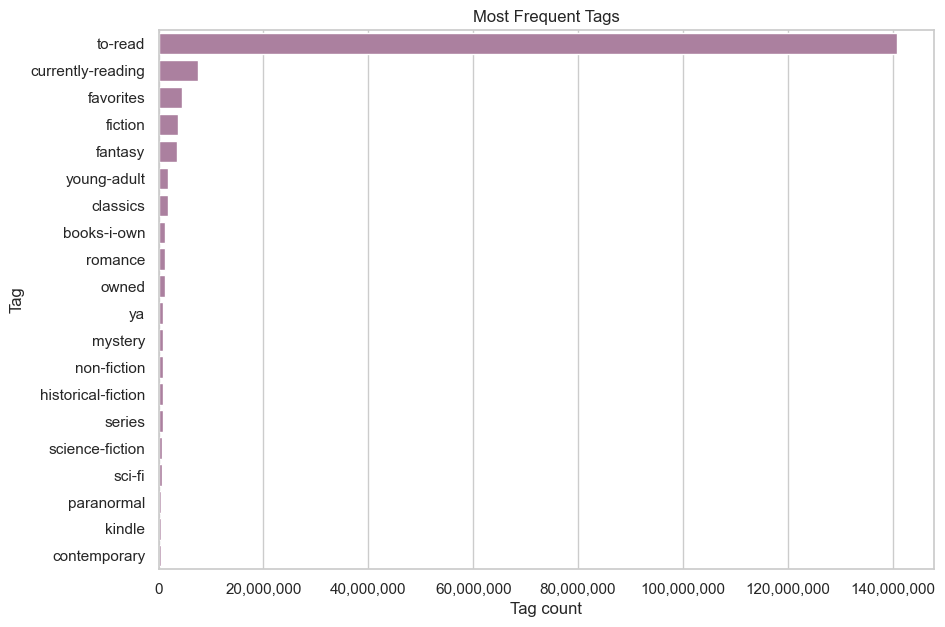

,tag_id,tag_count,tag_name
30574,30574,"140,718,761",to-read
8717,8717,"7,507,958",currently-reading
11557,11557,"4,503,173",favorites
11743,11743,"3,688,819",fiction
11305,11305,"3,548,157",fantasy
33114,33114,"1,848,306",young-adult
7457,7457,"1,756,920",classics
5207,5207,"1,317,235",books-i-own
26138,26138,"1,231,926",romance
22743,22743,"1,224,279",owned


In [18]:
top_tags = (
    book_tags.groupby("tag_id")["count"]
    .sum()
    .rename("tag_count")
    .reset_index()
    .merge(tags, on="tag_id", how="left")
    .sort_values("tag_count", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_tags, x="tag_count", y="tag_name", color="#B279A2", ax=ax)
integer_axis(ax, "x")
ax.set_title("Most Frequent Tags")
ax.set_xlabel("Tag count")
ax.set_ylabel("Tag")
plt.show()

top_tags.assign(tag_count=top_tags["tag_count"].map(fmt_int))

## Initial Findings

- `ratings.csv` has 5,976,479 ratings.

- These ratings come from 53,424 users and cover all 10,000 books.

- The data is very sparse
    Only 1.12% of possible user-book rating pairs are filled.
    So missing ratings is unknown, not disliked / rating 0

- The median user rated 111 books, about 1.1% of all books.

- Ratings are positive-skewed. Ratings 4 and 5 are much more common than 1 and 2.

- `to_read.csv` has 912,705 entries from 48,871 users and covers 9,986 books.

- Metadata has missing values, `language_code`, `isbn`, `isbn13`, and `original_title`.

- `title` is not unique. There are 36 duplicate title values.

- Generally use correct IDs:

     ratings/to_read -> books: use book_id
     book_tags -> books: use goodreads_book_id
     book_tags -> tags: use tag_id

- Popularity bias is likely
     Some books have far more ratings than others.
    If we only optimize naive accuracy, the recommender may mostly recommend popular books.